<a href="https://colab.research.google.com/github/starsyntaxx/Olist-delivery-prediction/blob/main/notebooks/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving final_ml_dataset.csv to final_ml_dataset.csv


In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("final_ml_dataset.csv")

In [ ]:
df.shape

(96455, 41)

In [6]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price_sum,price_mean,...,cross_state_delivery_mean,state_logistics_gap_mean,seller_state_freq_mean,customer_state_freq_mean,seller_state_tier_mean,customer_state_tier_mean,seller_geo_missing_max,customer_geo_missing_max,seller_state_nunique,seller_city_nunique
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,29.99,...,0.0,-0.291993,0.713200,0.421207,3.0,3.0,0,0,1,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,118.70,...,1.0,-0.679476,0.713200,0.033724,3.0,1.0,0,0,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,159.90,...,1.0,-0.692490,0.713200,0.020710,3.0,1.0,0,0,1,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,45.00,...,1.0,-0.073662,0.078358,0.004696,2.0,1.0,0,0,1,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,19.90,...,0.0,-0.291993,0.713200,0.421207,3.0,3.0,0,0,1,1


In [ ]:
model_df.head()

,order_status,order_estimated_delivery_date,price_sum,price_max,freight_value_sum,freight_value_max,order_item_id_count,product_id_nunique,seller_id_nunique,product_weight_g_sum,...,customer_state_freq_mean,seller_state_tier_mean,customer_state_tier_mean,seller_geo_missing_max,customer_geo_missing_max,seller_state_nunique,seller_city_nunique,product_volume_cm3,product_density,size_complexity
0,delivered,2017-10-18,29.99,29.99,8.72,8.72,1,1,1,500.0,...,0.421207,3.0,3.0,0,0,1,1,1976.0,0.253036,40.0
1,delivered,2018-08-13,118.70,118.70,22.76,22.76,1,1,1,400.0,...,0.033724,3.0,1.0,0,0,1,1,4693.0,0.085233,51.0
2,delivered,2018-09-04,159.90,159.90,19.22,19.22,1,1,1,420.0,...,0.020710,3.0,1.0,0,0,1,1,9576.0,0.043860,64.0
3,delivered,2017-12-15,45.00,45.00,27.20,27.20,1,1,1,450.0,...,0.004696,2.0,1.0,0,0,1,1,6000.0,0.075000,60.0
4,delivered,2018-02-26,19.90,19.90,8.72,8.72,1,1,1,250.0,...,0.421207,3.0,3.0,0,0,1,1,11475.0,0.021786,81.0


In [7]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [8]:
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.total_seconds() / 86400

In [9]:
df['approval_delay_days'] = (
    df['order_approved_at'] -
    df['order_purchase_timestamp']
).dt.total_seconds() / 86400

In [10]:
df['carrier_delay_days'] = (
    df['order_delivered_carrier_date'] -
    df['order_approved_at']
).dt.total_seconds() / 86400

In [11]:
df['transit_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_delivered_carrier_date']
).dt.total_seconds() / 86400

In [12]:
df['delivery_late_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.total_seconds() / 86400

Product measurement values

In [13]:
df['product_volume_cm3'] = (
    df['product_length_cm_mean'] *
    df['product_height_cm_mean'] *
    df['product_width_cm_mean']
)

In [14]:
df['product_density'] = (
    df['product_weight_g_sum'] /
    df['product_volume_cm3']
)

In [15]:
df['log_weight'] = np.log1p(df['product_weight_g_sum'])

In [16]:
df['size_complexity'] = (
    df['product_length_cm_mean'] +
    df['product_height_cm_mean'] +
    df['product_width_cm_mean']
)

In [46]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price_sum,price_mean,...,log_weight,size_complexity,log_volume,purchase_hour,purchase_day,purchase_dayofweek,purchase_month,purchase_week,purchase_quarter,is_weekend
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,29.99,...,6.216606,40.0,7.589336,10,2,0,10,40,4,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,118.70,...,5.993961,51.0,8.454040,20,24,1,7,30,3,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,159.90,...,6.042633,64.0,9.167120,8,8,2,8,32,3,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,45.00,...,6.111467,60.0,8.699681,19,18,5,11,46,4,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,19.90,...,5.525453,81.0,9.348013,21,13,1,2,7,1,0


In [17]:
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

df["purchase_day"] = df["order_purchase_timestamp"].dt.day

df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek

df["purchase_month"] = df["order_purchase_timestamp"].dt.month

df["purchase_week"] = df["order_purchase_timestamp"].dt.isocalendar().week.astype(int)

df["purchase_quarter"] = df["order_purchase_timestamp"].dt.quarter

df["is_weekend"] = (df["purchase_dayofweek"] >= 5).astype(int)

In [18]:
df["delivery_time_days"] = (

    df["order_delivered_customer_date"]
    -
    df["order_purchase_timestamp"]

).dt.days

In [19]:
df['log_volume'] = np.log1p(df['product_volume_cm3'])

In [35]:
# 1. Cyclical encoding for purchase hour (0–23)
df['purchase_hour_sin'] = np.sin(2 * np.pi * df['purchase_hour'] / 24.0)
df['purchase_hour_cos'] = np.cos(2 * np.pi * df['purchase_hour'] / 24.0)

# 2. Cyclical encoding for day of week (0–6)
df['purchase_dayofweek_sin'] = np.sin(2 * np.pi * df['purchase_dayofweek'] / 7.0)
df['purchase_dayofweek_cos'] = np.cos(2 * np.pi * df['purchase_dayofweek'] / 7.0)

# 3. Drop original columns
df = df.drop(columns=['purchase_hour', 'purchase_dayofweek'])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96455 entries, 0 to 96454
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   order_id                         96455 non-null  object        
 1   customer_id                      96455 non-null  object        
 2   order_status                     96455 non-null  object        
 3   order_purchase_timestamp         96455 non-null  datetime64[ns]
 4   order_approved_at                96455 non-null  datetime64[ns]
 5   order_delivered_carrier_date     96455 non-null  datetime64[ns]
 6   order_delivered_customer_date    96455 non-null  datetime64[ns]
 7   order_estimated_delivery_date    96455 non-null  datetime64[ns]
 8   price_sum                        96455 non-null  float64       
 9   price_mean                       96455 non-null  float64       
 10  price_max                        96455 non-null  float64  

In [37]:
cols_to_drop = [

    # identifiers
    "order_id",
    "customer_id",

    # leakage timestamps
    "order_delivered_carrier_date",
    "order_delivered_customer_date",

    # target leakage
    "carrier_delay_days",
    "transit_time_days",
    "delivery_late_days",

    # approval leakage
    "order_approved_at",
    "order_status",
    "approval_delay_days",

    # redundant means
    "price_mean",
    "freight_value_mean",

    # optional geographic redundancy
    #"lat_diff_mean",
    #"lng_diff_mean",

    #"product_weight_g_sum",
    #"product_weight_g_mean",
    #"product_length_cm_mean",
    #"product_height_cm_mean",
    #"product_width_cm_mean",
    #"purchase_week",
    #"purchase_quarter"
]

model_df = df.drop(columns=cols_to_drop)

In [38]:
model_df.drop(
    columns=["order_purchase_timestamp"],
    inplace=True
)

In [39]:
model_df.drop(
    columns=[
        "order_estimated_delivery_date"
    ],
    inplace=True
)

In [52]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96455 entries, 0 to 96454
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price_sum                        96455 non-null  float64
 1   price_max                        96455 non-null  float64
 2   freight_value_sum                96455 non-null  float64
 3   freight_value_max                96455 non-null  float64
 4   order_item_id_count              96455 non-null  int64  
 5   product_id_nunique               96455 non-null  int64  
 6   seller_id_nunique                96455 non-null  int64  
 7   product_weight_g_sum             96455 non-null  float64
 8   product_weight_g_mean            96439 non-null  float64
 9   product_photos_qty_mean          95124 non-null  float64
 10  product_name_lenght_mean         95124 non-null  float64
 11  product_description_lenght_mean  95124 non-null  float64
 12  delivery_distance_

In [40]:
num_cols = model_df.select_dtypes(include=["float64", "int64"]).columns

model_df[num_cols] = model_df[num_cols].fillna(
    model_df[num_cols].median()
)

In [41]:
def cap_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

    return df

In [42]:
outlier_cols = [
    "delivery_time_days",
    "price_sum",
    "freight_value_sum",
    "delivery_distance_km_mean",
    "product_weight_g_sum"
]

for col in outlier_cols:
    model_df = cap_outliers(model_df, col)

In [60]:
model_df.isnull().sum()

,0
price_sum,0
price_max,0
freight_value_sum,0
freight_value_max,0
order_item_id_count,0
product_id_nunique,0
seller_id_nunique,0
product_weight_g_sum,0
product_weight_g_mean,0
product_photos_qty_mean,0


In [43]:
# ==============================
# 1. Define Features and Target
# ==============================

X = model_df.drop(columns=['delivery_time_days'])
y = model_df['delivery_time_days']


# ==============================
# 2. Train-Test Split
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:


# ==============================
# 3. Train Model
# ==============================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Evaluate Model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 4.08776105437769
MSE: 28.87818253026598
R2 Score: 0.43198952595547235


In [ ]:
errors = y_test - y_pred

In [ ]:
error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = y_pred
error_df["error"] = errors
error_df["abs_error"] = errors.abs()

In [ ]:
error_df["error"].describe()

,error
count,19291.000000
mean,-0.231733
std,5.368983
min,-20.800000
25%,-3.605000
50%,-1.145000
75%,2.317500
max,25.630000


In [37]:
base_mae = mean_absolute_error(y_test, y_pred_base)
base_mse = mean_squared_error(y_test, y_pred_base)
base_r2 = r2_score(y_test, y_pred_base)

XG Boost

In [28]:
from xgboost import XGBRegressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import scipy.stats as stats

# 1. Base model
xgb_model = XGBRegressor(
    n_estimators=500,   # reduced for faster tuning
    random_state=42,
    n_jobs=-1
)

# 2. Hyperparameter space
param_dist = {
    'learning_rate': stats.uniform(0.01, 0.2),
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_child_weight': [1, 3, 5, 7, 10],
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'gamma': [0, 0.1, 0.2, 0.4, 1, 5]
}

# 3. Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,  # slightly more exploration
    scoring='neg_mean_absolute_error',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 5. Fit model
random_search.fit(X_train, y_train)

# 6. Results
print("Best Parameters:", random_search.best_params_)
print("Best MAE:", -random_search.best_score_)

# 7. Best model
best_xgb = random_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [44]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
y_pred_xgb = best_xgb.predict(X_test)

In [46]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("R2:", xgb_r2)

XGBoost Results
MAE: 3.9827661826657406
MSE: 27.803714524800696
R2: 0.4531234418620699


In [32]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

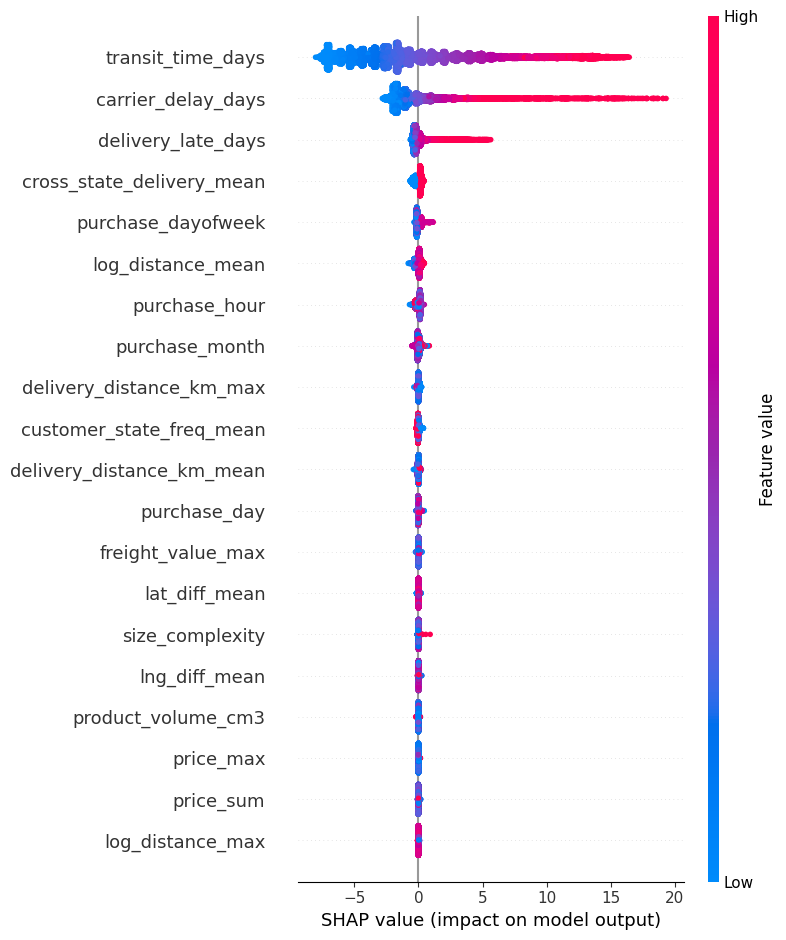

In [33]:
shap.summary_plot(shap_values, X_test)